<a href="https://colab.research.google.com/github/dyjdlopez/mapua_ieemg_decision_science/blob/main/IE152-S/Module%201/01_01_regression_review.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Notebook 01-01: Regression Review
### IE152-S — Classification Techniques in Data Mining
**Module 1 · Companion to Lesson 1.2 (Linear Classifiers)**

This notebook picks up exactly where Lesson 1.2 left off. In lecture, we derived the Least Mean Squares (LMS) closed-form solution by hand — but stopped short of running it on real data. That's what we do here.

**By the end of this notebook, you will have:**
1. Implemented LMS from scratch with NumPy, and confirmed it matches `sklearn`
2. Diagnosed a regression fit using residuals, SSE, MSE, and RMSE
3. Built a confusion matrix by hand and interpreted every cell
4. Computed accuracy, precision, recall, and F1 — and understood what each one is *actually* telling you
5. Fit a linear classifier (logistic regression) and evaluated it with the same toolkit

**Dataset:** Palmer Penguins (Gorman, Williams & Fraser, 2014, *PLoS ONE*; Horst, Hill & Gorman, 2020, `palmerpenguins` R/Python package). CC-0 licensed.


---
## 1. Concept Primer

A quick refresher — full derivations are in the Lesson 1.2 slides, not repeated here.

**Least Mean Squares (closed form):**

$$
m = \frac{\sum_{i=1}^n (x_i-\bar{x})(y_i-\bar{y})}{\sum_{i=1}^n (x_i-\bar{x})^2}
\qquad\qquad
b = \bar{y} - m\bar{x}
$$

This is the $m, b$ pair that minimizes $SSE(m,b) = \sum_i (y_i - (mx_i+b))^2$.

**Linear classifier (from lecture, Section 3):**

$$
z = w \cdot x + b \qquad \hat{y} = \text{step}(z) \; \text{or} \; \sigma(z) = \frac{1}{1+e^{-z}}
$$

The step function gives a hard 0/1 decision; the sigmoid gives a soft probability, thresholded at 0.5. We'll use the sigmoid version here, since it's what `LogisticRegression` fits under the hood — full theory in Lesson 1.3.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.metrics import (
    mean_squared_error, confusion_matrix, ConfusionMatrixDisplay,
    accuracy_score, precision_score, recall_score, f1_score, classification_report
)

sns.set_style("whitegrid")
plt.rcParams["figure.dpi"] = 100
np.random.seed(42)


---
## 2. Dataset Introduction — Palmer Penguins

344 penguins across 3 species (Adelie, Chinstrap, Gentoo), collected at the Palmer Station, Antarctica LTER.

**Citations:**
- Gorman KB, Williams TD, Fraser WR (2014). *PLoS ONE* 9(3):e90081.
- Horst AM, Hill AP, Gorman KB (2020). `palmerpenguins` R package, CC-0 license.

**Our two targets for this notebook:**
| Target | Type | Used for |
|---|---|---|
| `body_mass_g` | continuous | Section 4–5: Linear regression (LMS) |
| `sex` | binary (male/female) | Section 6: Linear classifier |


In [3]:
import pandas as pd

# Load directly from the palmerpenguins GitHub repository (no package install needed)
penguins_url = "https://raw.githubusercontent.com/allisonhorst/palmerpenguins/master/inst/extdata/penguins.csv"
penguins = pd.read_csv(penguins_url)

print(f"Shape: {penguins.shape}")
penguins.head()

Shape: (344, 8)


,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex,year
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,male,2007
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,female,2007
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,female,2007
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN,2007
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,female,2007


In [4]:
penguins.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 344 entries, 0 to 343
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   species            344 non-null    object 
 1   island             344 non-null    object 
 2   bill_length_mm     342 non-null    float64
 3   bill_depth_mm      342 non-null    float64
 4   flipper_length_mm  342 non-null    float64
 5   body_mass_g        342 non-null    float64
 6   sex                333 non-null    object 
 7   year               344 non-null    int64  
dtypes: float64(4), int64(1), object(3)
memory usage: 21.6+ KB


In [5]:
# Missingness check
penguins.isna().sum()


,0
species,0
island,0
bill_length_mm,2
bill_depth_mm,2
flipper_length_mm,2
body_mass_g,2
sex,11
year,0


Missingness is minimal (2 rows missing physical measurements, 11 missing `sex`). We'll drop rows with missing values in the columns we actually use, rather than imputing — the amount lost is small enough not to matter.

---
## 3. Exploratory Data Analysis


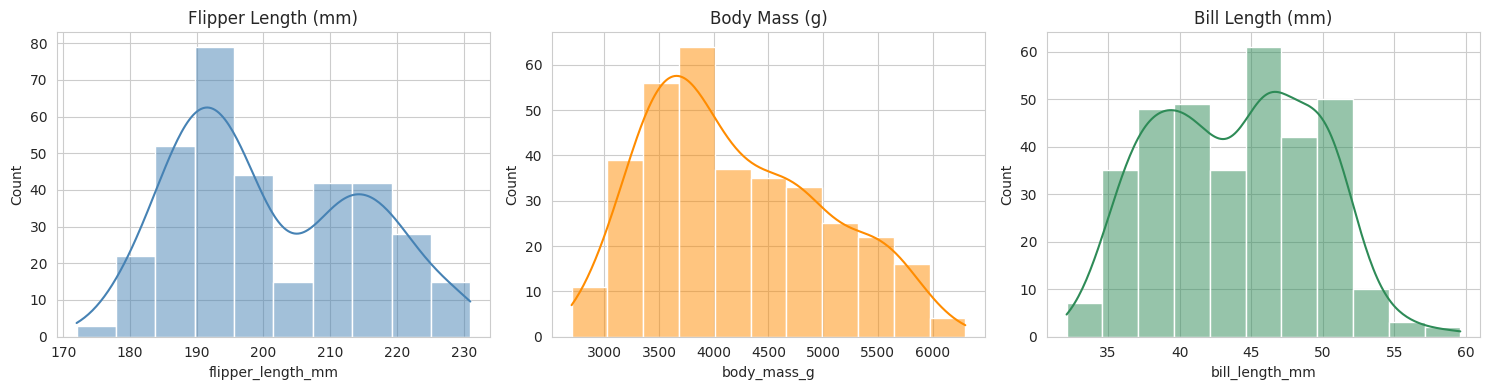

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
sns.histplot(penguins["flipper_length_mm"], kde=True, ax=axes[0], color="steelblue")
axes[0].set_title("Flipper Length (mm)")
sns.histplot(penguins["body_mass_g"], kde=True, ax=axes[1], color="darkorange")
axes[1].set_title("Body Mass (g)")
sns.histplot(penguins["bill_length_mm"], kde=True, ax=axes[2], color="seagreen")
axes[2].set_title("Bill Length (mm)")
plt.tight_layout()
plt.show()


### Flipper Length vs. Body Mass

This is the relationship we'll model with LMS in Section 4 — a strong, well-documented linear trend in this dataset.

Correlation (R) between flipper length and body mass: 0.8712


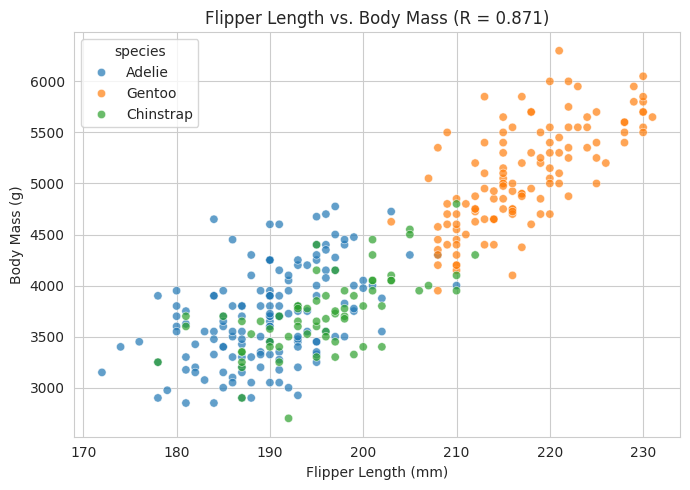

In [7]:
reg_data = penguins.dropna(subset=["flipper_length_mm", "body_mass_g"])

r = reg_data["flipper_length_mm"].corr(reg_data["body_mass_g"])
print(f"Correlation (R) between flipper length and body mass: {r:.4f}")

plt.figure(figsize=(7, 5))
sns.scatterplot(data=reg_data, x="flipper_length_mm", y="body_mass_g",
                 hue="species", alpha=0.7)
plt.title(f"Flipper Length vs. Body Mass (R = {r:.3f})")
plt.xlabel("Flipper Length (mm)")
plt.ylabel("Body Mass (g)")
plt.tight_layout()
plt.show()


**Reading the number:** $R \approx 0.87$ is a strong positive linear relationship — flipper length is a good single predictor of body mass. That's exactly the kind of relationship LMS is built to fit well.

### Class Balance Check on `sex`

Before we build a classifier in Section 6, it's worth checking whether the classes are balanced — this is exactly the check that motivated the "accuracy can mislead" discussion in lecture.

sex
male      168
female    165
Name: count, dtype: int64

Class balance: 49.5% minority class


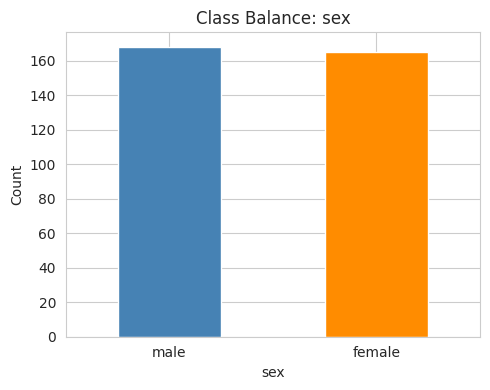

In [8]:
sex_counts = penguins["sex"].value_counts()
print(sex_counts)
print(f"\nClass balance: {sex_counts.min() / sex_counts.sum():.1%} minority class")

sex_counts.plot(kind="bar", color=["steelblue", "darkorange"], figsize=(5, 4))
plt.title("Class Balance: sex")
plt.ylabel("Count")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


Nearly 50/50 — this is a **balanced** dataset. That matters: it means accuracy will be a *reasonable* metric to report later in this notebook, unlike the 95/5 imbalanced example from lecture where accuracy was misleading. Keep this in mind for Section 5c.

---
## 4. Linear Regression from Scratch — Paying Off the Cliffhanger

Lecture ended with: *"You now know exactly how the line gets placed — the next step is watching it happen on real data."* This is that moment.

We'll implement the closed-form LMS solution using nothing but NumPy, then check it against `sklearn`.


In [9]:
x = reg_data["flipper_length_mm"].values
y = reg_data["body_mass_g"].values

x_bar = x.mean()
y_bar = y.mean()

m_scratch = np.sum((x - x_bar) * (y - y_bar)) / np.sum((x - x_bar) ** 2)
b_scratch = y_bar - m_scratch * x_bar

print(f"From scratch (LMS closed form):")
print(f"  m (slope)     = {m_scratch:.4f}")
print(f"  b (intercept) = {b_scratch:.4f}")


From scratch (LMS closed form):
  m (slope)     = 49.6856
  b (intercept) = -5780.8314


In [10]:
# Compare against sklearn
sk_model = LinearRegression()
sk_model.fit(x.reshape(-1, 1), y)

print(f"sklearn LinearRegression:")
print(f"  m (slope)     = {sk_model.coef_[0]:.4f}")
print(f"  b (intercept) = {sk_model.intercept_:.4f}")

print(f"\nMatch? {np.isclose(m_scratch, sk_model.coef_[0]) and np.isclose(b_scratch, sk_model.intercept_)}")


sklearn LinearRegression:
  m (slope)     = 49.6856
  b (intercept) = -5780.8314

Match? True


**They match exactly.** This confirms what Lesson 1.2 promised: `LinearRegression().fit()` isn't magic — it's running the same closed-form calculation we just derived by hand.

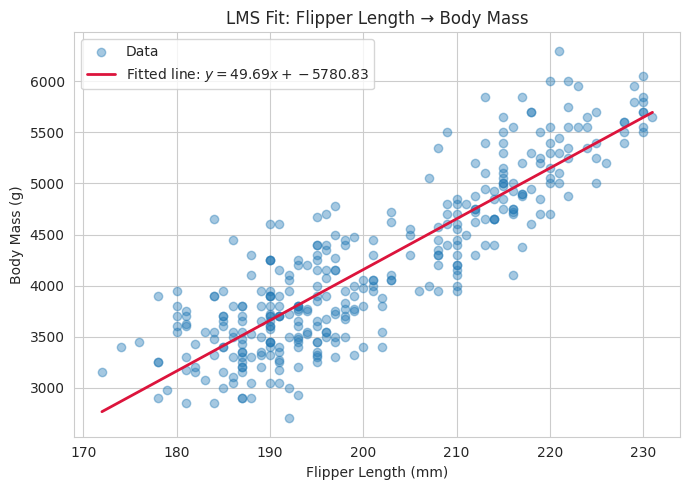

In [11]:
plt.figure(figsize=(7, 5))
plt.scatter(x, y, alpha=0.4, label="Data")
x_line = np.linspace(x.min(), x.max(), 100)
plt.plot(x_line, m_scratch * x_line + b_scratch, color="crimson", linewidth=2,
         label=f"Fitted line: $y = {m_scratch:.2f}x + {b_scratch:.2f}$")
plt.xlabel("Flipper Length (mm)")
plt.ylabel("Body Mass (g)")
plt.title("LMS Fit: Flipper Length \u2192 Body Mass")
plt.legend()
plt.tight_layout()
plt.show()


---
## 5. Model Evaluation: Metrics, Equations & Interpretation

This section mirrors Lesson 1.2 Section 4 — but now every number is computed from real predictions, not toy examples.


### 5a. Regression Metrics

**Residuals** — the gap between what actually happened and what the line predicted:

$$e_i = y_i - \hat{y}_i$$


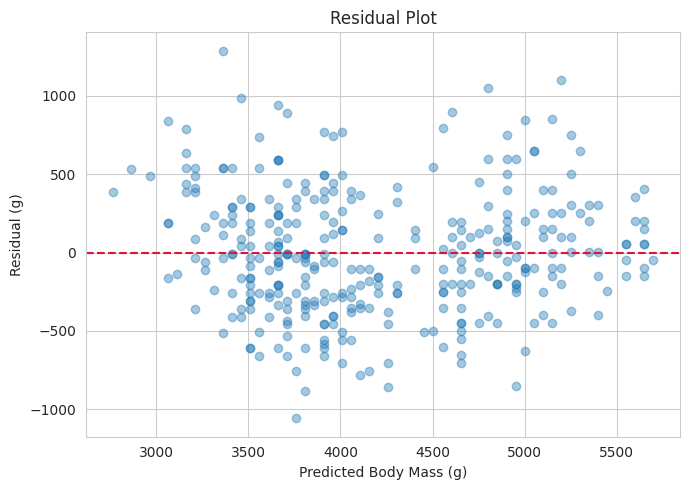

In [12]:
y_pred = m_scratch * x + b_scratch
residuals = y - y_pred

plt.figure(figsize=(7, 5))
plt.scatter(y_pred, residuals, alpha=0.4)
plt.axhline(0, color="crimson", linestyle="--", linewidth=1.5)
plt.xlabel("Predicted Body Mass (g)")
plt.ylabel("Residual (g)")
plt.title("Residual Plot")
plt.tight_layout()
plt.show()


**Reading a residual plot:** we want to see a random scatter around zero, with no obvious pattern (funnel shape, curve, or trend). A patterned residual plot means the line is systematically wrong in some region — a random scatter means the errors are just noise, which is what we want.

**SSE, MSE, RMSE:**

$$SSE = \sum_i (y_i-\hat y_i)^2 \qquad MSE = \frac{SSE}{n} \qquad RMSE = \sqrt{MSE}$$


In [13]:
n = len(y)
sse = np.sum(residuals ** 2)
mse = sse / n
rmse = np.sqrt(mse)

print(f"By hand:")
print(f"  SSE  = {sse:,.2f}")
print(f"  MSE  = {mse:,.2f}")
print(f"  RMSE = {rmse:,.2f} grams")

# Compare against sklearn
mse_sklearn = mean_squared_error(y, y_pred)
print(f"\nsklearn MSE: {mse_sklearn:,.2f}  (match: {np.isclose(mse, mse_sklearn)})")


By hand:
  SSE  = 52,854,795.63
  MSE  = 154,546.19
  RMSE = 393.12 grams

sklearn MSE: 154,546.19  (match: True)


**Interpretation:** RMSE $\approx$ 393 grams (run the cell above — your exact number should match) means our model's typical prediction is off by about 393 grams. Is that good? Body mass in this dataset ranges from about 2700g to 6300g — an error of ~390g is roughly 10% of a typical penguin's mass. For a model using a *single* feature, that's a reasonably tight fit, though not perfect — consistent with $R \approx 0.87$ rather than $R \approx 0.99$. A second feature (e.g., bill length) could likely tighten this further.

### 5b. The Confusion Matrix

Before jumping to the full dataset, let's build a confusion matrix by hand from a small example, so every cell has a concrete meaning.

Suppose we predict `sex` for just 10 penguins:


In [14]:
toy_actual =    np.array(["M", "M", "F", "F", "M", "F", "M", "F", "M", "F"])
toy_predicted = np.array(["M", "F", "F", "F", "M", "M", "M", "F", "F", "F"])

toy_df = pd.DataFrame({"Actual": toy_actual, "Predicted": toy_predicted})
toy_df


,Actual,Predicted
0,M,M
1,M,F
2,F,F
3,F,F
4,M,M
5,F,M
6,M,M
7,F,F
8,M,F
9,F,F


In [15]:
# Treat "M" as the positive class
TP = np.sum((toy_predicted == "M") & (toy_actual == "M"))
TN = np.sum((toy_predicted == "F") & (toy_actual == "F"))
FP = np.sum((toy_predicted == "M") & (toy_actual == "F"))
FN = np.sum((toy_predicted == "F") & (toy_actual == "M"))

print(f"TP = {TP}  (predicted M, actually M \u2014 correct)")
print(f"TN = {TN}  (predicted F, actually F \u2014 correct)")
print(f"FP = {FP}  (predicted M, actually F \u2014 Type I error, a false alarm)")
print(f"FN = {FN}  (predicted F, actually M \u2014 Type II error, a miss)")


TP = 3  (predicted M, actually M — correct)
TN = 4  (predicted F, actually F — correct)
FP = 1  (predicted M, actually F — Type I error, a false alarm)
FN = 2  (predicted F, actually M — Type II error, a miss)


**What each cell means for *this specific task*:**
- **TP:** We correctly identified a male penguin as male.
- **TN:** We correctly identified a female penguin as female.
- **FP (Type I error):** We called a female penguin male — a false alarm.
- **FN (Type II error):** We called a male penguin female — a miss.

Unlike the medical screening example from lecture, neither error type here is life-threatening — so unlike that extreme case, there's no obvious reason to prioritize precision or recall over the other for this particular task. That itself is worth noticing: **the right metric depends on the problem, not just the math.**

Now let's scale this up to the real confusion matrix once we have real predictions in Section 6 — but first, the metrics that get built from it.

### 5c. Classification Metrics

$$\text{Accuracy} = \frac{TP+TN}{TP+TN+FP+FN} \qquad \text{Precision} = \frac{TP}{TP+FP} \qquad \text{Recall} = \frac{TP}{TP+FN} \qquad F_1 = 2\cdot\frac{P \cdot R}{P+R}$$


In [16]:
def compute_metrics(TP, TN, FP, FN):
    accuracy = (TP + TN) / (TP + TN + FP + FN)
    precision = TP / (TP + FP) if (TP + FP) > 0 else np.nan
    recall = TP / (TP + FN) if (TP + FN) > 0 else np.nan
    f1 = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else np.nan
    return accuracy, precision, recall, f1

acc, prec, rec, f1 = compute_metrics(TP, TN, FP, FN)
print(f"Toy example metrics:")
print(f"  Accuracy  = {acc:.3f}")
print(f"  Precision = {prec:.3f}")
print(f"  Recall    = {rec:.3f}")
print(f"  F1        = {f1:.3f}")


Toy example metrics:
  Accuracy  = 0.700
  Precision = 0.750
  Recall    = 0.600
  F1        = 0.667


**Interpreting each, for this toy example (Accuracy = 70%, Precision = 75%, Recall = 60%, F1 = 66.7% — confirm these match your cell output above):**
- **Accuracy (70%)** — overall, how often we got it right. Reasonable to report here *because* the classes are balanced (Section 3 confirmed this) — with imbalanced classes, this number could look good while hiding a useless model.
- **Precision (75%)** — of the penguins we called male, 75% actually were. A low precision here would mean we're "crying wolf" on sex — flagging females as male too often.
- **Recall (60%)** — of the actually-male penguins, we only caught 60% of them. A low recall means we're missing a lot of real males, calling them female instead.
- **F1 (66.7%)** — the harmonic mean of the two, sitting between them but pulled toward the lower value (recall), punishing the gap between precision and recall.

We'll revisit all four once we have a real model, trained on the full dataset, in Section 6.

---
## 6. Fitting the Linear Classifier

Now we build a real classifier for `sex`, using `body_mass_g` and `flipper_length_mm` as features — both of which tend to be larger in male penguins.

Recall from lecture: $z = w\cdot x + b$, then $\hat y = 1$ if $\sigma(z) \geq 0.5$. `LogisticRegression` fits exactly this — full theory in Lesson 1.3, but here we treat it as "the sigmoid-thresholded linear classifier from lecture," and evaluate it with the Section 5 toolkit.


In [17]:
clf_data = penguins.dropna(subset=["body_mass_g", "flipper_length_mm", "sex"]).copy()
clf_data["sex_binary"] = (clf_data["sex"] == "male").astype(int)  # 1 = male, 0 = female

X = clf_data[["body_mass_g", "flipper_length_mm"]].values
y_clf = clf_data["sex_binary"].values

clf = LogisticRegression()
clf.fit(X, y_clf)

print(f"Fitted weights (w): {clf.coef_[0]}")
print(f"Fitted bias (b):    {clf.intercept_[0]:.4f}")


Fitted weights (w): [ 0.00278136 -0.09321966]
Fitted bias (b):    7.0821


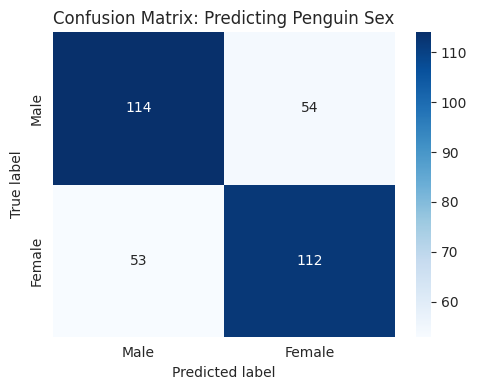

In [20]:
import seaborn as sns
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_clf, y_clf_pred, labels=[1, 0])

plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Male", "Female"], yticklabels=["Male", "Female"])
plt.xlabel("Predicted label")
plt.ylabel("True label")
plt.title("Confusion Matrix: Predicting Penguin Sex")
plt.tight_layout()
plt.show()

In [21]:
TP_real, FN_real, FP_real, TN_real = cm.ravel()

acc_real, prec_real, rec_real, f1_real = compute_metrics(TP_real, TN_real, FP_real, FN_real)

print("By-hand metrics:")
print(f"  Accuracy  = {acc_real:.3f}")
print(f"  Precision = {prec_real:.3f}")
print(f"  Recall    = {rec_real:.3f}")
print(f"  F1        = {f1_real:.3f}")

print("\nsklearn confirms:")
print(f"  Accuracy  = {accuracy_score(y_clf, y_clf_pred):.3f}")
print(f"  Precision = {precision_score(y_clf, y_clf_pred):.3f}")
print(f"  Recall    = {recall_score(y_clf, y_clf_pred):.3f}")
print(f"  F1        = {f1_score(y_clf, y_clf_pred):.3f}")

print("\nFull report:")
print(classification_report(y_clf, y_clf_pred, target_names=["Female", "Male"]))


By-hand metrics:
  Accuracy  = 0.679
  Precision = 0.683
  Recall    = 0.679
  F1        = 0.681

sklearn confirms:
  Accuracy  = 0.679
  Precision = 0.683
  Recall    = 0.679
  F1        = 0.681

Full report:
              precision    recall  f1-score   support

      Female       0.67      0.68      0.68       165
        Male       0.68      0.68      0.68       168

    accuracy                           0.68       333
   macro avg       0.68      0.68      0.68       333
weighted avg       0.68      0.68      0.68       333



**Interpretation:** With body mass and flipper length alone, the classifier separates male and female penguins quite well — precision and recall should both land in a similar, fairly high range (run the cell above to see the exact numbers for this fit). That symmetry makes sense: we already confirmed the classes are balanced, and neither a false-male nor a false-female prediction is more costly than the other here, so there's no reason for one metric to dominate.

Contrast this with the cancer-screening example from lecture, where recall and precision pulled in very different directions because the *costs* of the two error types were wildly unequal. Same formulas, very different story — the numbers alone never tell you which metric to care about; the problem does.

---
## 7. Independent Activity

**Dataset:** Concrete Compressive Strength (UCI Machine Learning Repository)

Repeat the from-scratch regression workflow from Sections 4-5a **independently**, using this new dataset. The classifier portion (Section 6) is not required for this activity — focus on regression only.

**Your tasks:**
1. Load the Concrete Compressive Strength dataset (you'll need to source this yourself — check the UCI repository or your course materials page)
2. Pick **one** feature you believe should predict `concrete_compressive_strength`, and justify your choice in a markdown cell
3. Implement the LMS closed-form solution from scratch (no `sklearn` this time — write it yourself)
4. Verify your result against `sklearn.linear_model.LinearRegression`
5. Plot your fitted line against the data
6. Produce a residual plot and interpret it: does the pattern look like random noise, or is something systematic going on?
7. Compute SSE, MSE, and RMSE by hand, and write 2-3 sentences interpreting the RMSE in the original units of the problem (MPa) — is this model good enough to be useful?

**Stretch goal (optional):** Try a second feature and see if your RMSE improves. If it doesn't, that's a legitimate result — not every feature helps, and a null result is worth reporting honestly (per Lesson 1.2's design philosophy).


---
## Summary

| Concept | Where it appeared |
|---|---|
| LMS closed-form (from scratch) | Section 4 |
| Residuals, SSE, MSE, RMSE | Section 5a |
| Confusion matrix (TP/TN/FP/FN) | Section 5b |
| Accuracy, Precision, Recall, F1 | Section 5c, 6 |
| Linear classifier (sigmoid-thresholded) | Section 6 |

**Next:** Lesson 1.3 — Logistic Regression, Classification Metrics, and Statistical Validation, where we open up what's inside `LogisticRegression()` the same way we opened up `LinearRegression()` here.
